# Trace Miss Correction

This demo shows how `SimParams` can be configured to handle trace miss
events, where the vehicle cannot achieve the target speed.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import fastsim as fsim

In [2]:
sns.set_theme()

SHOW_PLOTS = os.environ.get("SHOW_PLOTS", "true").lower() == "true"
SAVE_FIGS = os.environ.get("SAVE_FIGS", "false").lower() == "true"

## Build a Custom Cycle

This cycle has a sharp acceleration from 0 to 8 m/s in one second,
which the vehicle cannot fully achieve (a trace miss).

In [3]:
cyc_d = {
    "time_seconds": [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0],
    "speed_meters_per_second": [0.0, 0.0, 8.0, 8.0, 8.0, 8.0, 8.0, 0.0, 0.0],
}
cyc = fsim.Cycle.from_pydict(cyc_d)
cyc0 = cyc.copy()

In [4]:
veh = fsim.Vehicle.from_resource("2012_Ford_Fusion.yaml")
veh.set_save_interval(1)

## Configure Trace Miss Options

`TraceMissOptions` controls what happens when the vehicle cannot match
the target speed:
- `"Allow"`: allow trace miss without any correction
- `"AllowChecked"`: allow trace miss within error tolerance
- `"Error"` (default): throw error when trace miss happens
- `"Correct"`: correct trace miss with driver model that catches up

`trace_miss_correct_max_steps` is the maximum number of steps in which to
re-rendezvous with the reference trace. The trajectory with the smallest
peak acceleration is chosen. Must be 2 or greater; defaults to 6.

In [5]:
params = fsim.SimParams.default().to_pydict()
params["trace_miss_opts"] = "Correct"
params["trace_miss_correct_max_steps"] = 6

sd = fsim.SimDrive(veh, cyc, fsim.SimParams.from_pydict(params))
sd.walk()

## Results

Original cycle speed vs. achieved speed with trace miss correction.

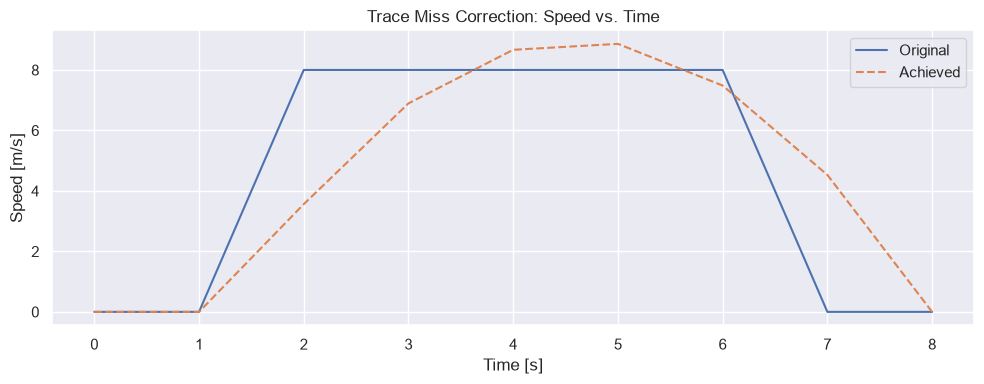

In [6]:
if SHOW_PLOTS:
    c0 = cyc0.to_pydict()
    df = sd.to_dataframe(backend='polars')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        np.array(c0["time_seconds"]),
        np.array(c0["speed_meters_per_second"]),
        label="Original",
    )
    ax.plot(
        np.array(df["cyc.time_seconds"]),
        np.array(df["veh.history.speed_ach_meters_per_second"]),
        linestyle="--",
        label="Achieved",
    )
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Speed [m/s]")
    ax.set_title("Trace Miss Correction: Speed vs. Time")
    ax.legend()
    plt.tight_layout()
    plt.show()

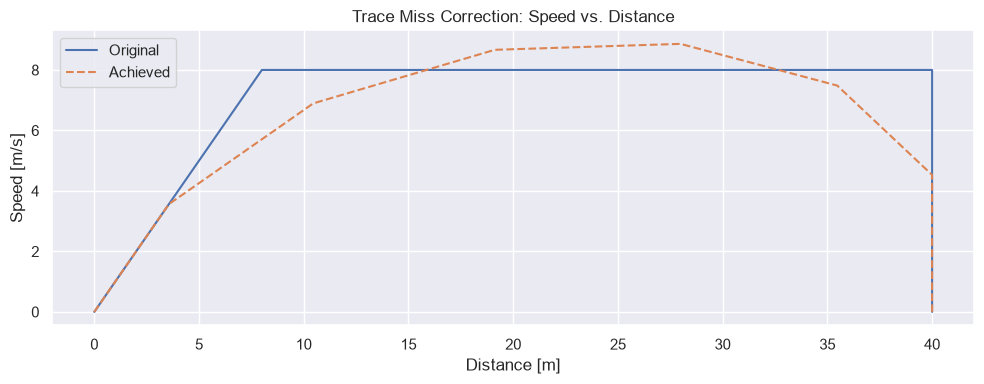

In [7]:
if SHOW_PLOTS:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        np.array(c0["dist_meters"]),
        np.array(c0["speed_meters_per_second"]),
        label="Original",
    )
    ax.plot(
        np.array(df["cyc.dist_meters"]),
        np.array(df["veh.history.speed_ach_meters_per_second"]),
        linestyle="--",
        label="Achieved",
    )
    ax.set_xlabel("Distance [m]")
    ax.set_ylabel("Speed [m/s]")
    ax.set_title("Trace Miss Correction: Speed vs. Distance")
    ax.legend()
    plt.tight_layout()
    plt.show()

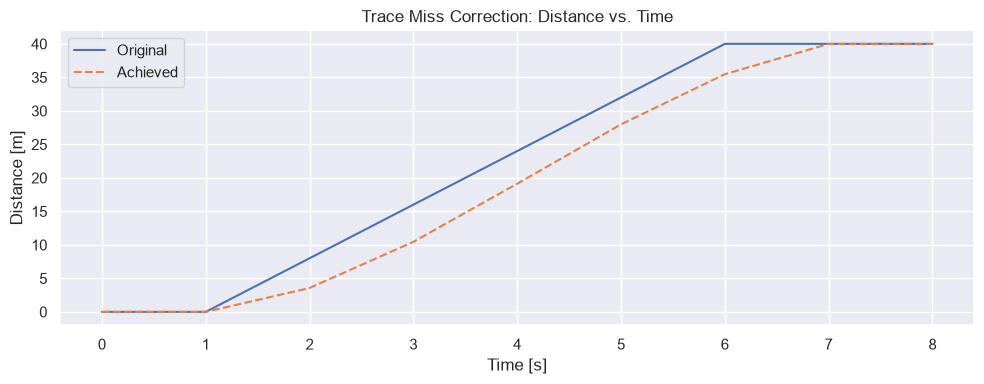

In [8]:
if SHOW_PLOTS:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        np.array(c0["time_seconds"]),
        np.array(c0["dist_meters"]),
        label="Original",
    )
    ax.plot(
        np.array(df["cyc.time_seconds"]),
        np.array(df["cyc.dist_meters"]),
        linestyle="--",
        label="Achieved",
    )
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Distance [m]")
    ax.set_title("Trace Miss Correction: Distance vs. Time")
    ax.legend()
    plt.tight_layout()
    plt.show()